# PARA Dataset — Exploratory Data Analysis

**PARA** (*Personalized image Aesthetics assessment with Rich Attributes*, Yang et al.)
is a personalized image-aesthetics dataset. Every image is rated by ~26 human
annotators, and every annotator has a known demographic + Big-Five personality
profile. That makes PARA a *personalized* aesthetics benchmark: the same image can
be liked differently by different people.

This notebook answers three questions:

1. **What features does the dataset have?** — structure, columns, types, coverage.
2. **How are they distributed?** — univariate distributions of scores, scenes,
   emotions, and annotator attributes.
3. **What correlates with what?** — attribute-vs-attribute correlations, what drives
   the aesthetic score, and whether annotator traits predict the scores they give.

**Data files used** (`data/PARA/annotation/`):

| File | Grain | What it is |
|------|-------|------------|
| `PARA-Images.csv` | one row **per (image, annotator)** | the raw PIAA annotations — every score in the dataset |
| `PARA-UserInfo.csv` | one row **per annotator** | demographics + Big-Five personality |

(`PARA-GiaaTrain.csv` / `PARA-GiaaTest.csv` are pre-aggregated per-image score
*distributions* derived from `PARA-Images.csv` for the generic-IAA task; we analyse
the raw signal instead.)

In [1]:
# --- Imports & configuration -------------------------------------------------
import os, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# Validated, colour-blind-safe palette (from the dataviz design system) --------
CATEGORICAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
               "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
BLUE, AQUA, VIOLET, RED = "#2a78d6", "#1baf7a", "#4a3aa7", "#e34948"

# Diverging blue <-> red with a neutral grey midpoint -> for correlations (polarity)
DIVERGING = LinearSegmentedColormap.from_list(
    "blue_grey_red", ["#184f95", "#2a78d6", "#f0efec", "#e34948", "#a01f1f"])

mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#ececec", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "figure.dpi": 110,
})
print("pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", mpl.__version__)

pandas 3.0.3 | numpy 2.4.6 | matplotlib 3.11.0


In [2]:
# --- Locate the annotation directory (works regardless of run cwd) -----------
def find_annotation_dir():
    for c in ["../data/PARA/annotation", "data/PARA/annotation",
              "../../data/PARA/annotation"]:
        if os.path.isdir(c):
            return c
    here = os.path.abspath(".")
    for _ in range(6):
        cand = os.path.join(here, "data", "PARA", "annotation")
        if os.path.isdir(cand):
            return cand
        here = os.path.dirname(here)
    raise FileNotFoundError("Could not locate data/PARA/annotation")

ANN = find_annotation_dir()
print("Annotation dir:", os.path.abspath(ANN))

images = pd.read_csv(os.path.join(ANN, "PARA-Images.csv"))
users  = pd.read_csv(os.path.join(ANN, "PARA-UserInfo.csv"))
print("PARA-Images   :", images.shape)
print("PARA-UserInfo :", users.shape)
images.head()

Annotation dir: /shared/amin/code/playground/image-society/data/PARA/annotation


PARA-Images   : (807586, 16)
PARA-UserInfo : (438, 11)


,sessionId,imageName,userId,aestheticScore,qualityScore,compositionScore,colorScore,dofScore,contentScore,lightScore,isObjectEmphasis,imgEmotion,difficultyOfJudgment,contentPreference,willingnessToShare,semantic
0,session1,iaa_pub1_.jpg,A3c6418,3.0,3.1,3,4,3,3,4,0,neutral,-1,3,3,animal
1,session1,iaa_pub2_.jpg,A3c6418,3.0,2.9,3,4,4,3,4,0,neutral,-1,3,3,stilllife
2,session1,iaa_pub3_.jpg,A3c6418,3.0,3.1,3,4,4,3,4,0,neutral,-1,4,4,portrait
3,session1,iaa_pub4_.jpg,A3c6418,2.5,2.4,2,3,3,2,3,0,neutral,-1,2,2,plant
4,session1,iaa_pub5_.jpg,A3c6418,3.5,3.4,3,4,4,3,4,0,neutral,-1,3,3,stilllife


## 1. Dataset structure & features

### Feature dictionary — `PARA-Images.csv` (one row per image × annotator)

| Column | Type | Meaning |
|--------|------|---------|
| `sessionId` | id | capture/annotation session the image belongs to |
| `imageName` | id | image filename (links to `imgs/<session>/...`) |
| `userId` | id | annotator id (links to `PARA-UserInfo.csv`) |
| `aestheticScore` | 1–5 | overall aesthetic rating |
| `qualityScore` | 1–5 | technical image quality |
| `compositionScore` | 1–5 | composition |
| `colorScore` | 1–5 | colour |
| `dofScore` | 1–5 | depth-of-field |
| `contentScore` | 1–5 | content |
| `lightScore` | 1–5 | lighting |
| `contentPreference` | 1–5 | how much the annotator likes the *content* |
| `willingnessToShare` | 1–5 | would the annotator share it |
| `isObjectEmphasis` | 0/1 | is there a clear emphasised subject |
| `difficultyOfJudgment` | −1/0/1 | easy / normal / difficult to judge |
| `imgEmotion` | class (8) | evoked emotion (neutral, awe, amusement, …) |
| `semantic` | class (10) | scene category (portrait, animal, food, …) |

### Feature dictionary — `PARA-UserInfo.csv` (one row per annotator)

| Column | Type | Meaning |
|--------|------|---------|
| `userId` | id | annotator id |
| `age` | ordinal | age interval (18-21 … 35-40) |
| `gender` | class | female / male |
| `EducationalLevel` | class | education level |
| `artExperience` | ordinal | beginner → competent → proficient → expert |
| `photographyExperience` | ordinal | beginner → … → expert |
| `personality-E/A/N/O/C` | 2–10 | Big-Five: Extraversion, Agreeableness, Neuroticism, Openness, Conscientiousness |

In [3]:
# --- Types, missing values, memory -------------------------------------------
print("PARA-Images.csv  -> {:,} rows x {} cols, {:.1f} MB in memory".format(
      *images.shape, images.memory_usage(deep=True).sum()/1e6))
print("Missing values (Images):", int(images.isna().sum().sum()))
print("Missing values (Users) :", int(users.isna().sum().sum()))

info = pd.DataFrame({"dtype": images.dtypes.astype(str),
                     "n_unique": images.nunique(),
                     "example": images.iloc[0].astype(str)})
display(info)

PARA-Images.csv  -> 807,586 rows x 16 cols, 142.0 MB in memory
Missing values (Images): 0
Missing values (Users) : 0


,dtype,n_unique,example
sessionId,str,446,session1
imageName,str,31220,iaa_pub1_.jpg
userId,str,438,A3c6418
aestheticScore,float64,9,3.0
qualityScore,float64,41,3.1
compositionScore,int64,5,3
colorScore,int64,5,4
dofScore,int64,5,3
contentScore,int64,5,3
lightScore,int64,5,4


Unique images          : 31,220
Unique annotators      : 438
Sessions               : 446
Total PIAA annotations : 807,586



Annotations per image  : mean 25.9  (min 20, max 38)
Annotations per user   : mean 1844  (min 70, max 3570)


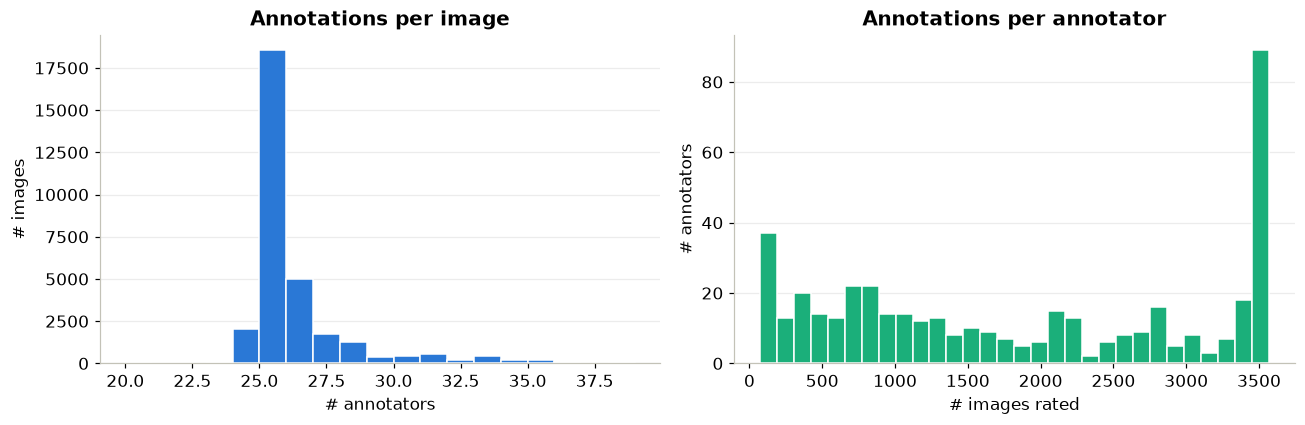

In [4]:
# --- Annotation coverage -----------------------------------------------------
n_imgs, n_users, n_sess = images.imageName.nunique(), images.userId.nunique(), images.sessionId.nunique()
print(f"Unique images          : {n_imgs:,}")
print(f"Unique annotators      : {n_users:,}")
print(f"Sessions               : {n_sess:,}")
print(f"Total PIAA annotations : {len(images):,}")

per_img = images.groupby("imageName").size()
per_usr = images.groupby("userId").size()
print(f"\nAnnotations per image  : mean {per_img.mean():.1f}  (min {per_img.min()}, max {per_img.max()})")
print(f"Annotations per user   : mean {per_usr.mean():.0f}  (min {per_usr.min()}, max {per_usr.max()})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(per_img, bins=range(per_img.min(), per_img.max()+2), color=BLUE, edgecolor="white")
ax[0].set(title="Annotations per image", xlabel="# annotators", ylabel="# images")
ax[1].hist(per_usr, bins=30, color=AQUA, edgecolor="white")
ax[1].set(title="Annotations per annotator", xlabel="# images rated", ylabel="# annotators")
for a in ax: a.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 2. Univariate distributions

### 2.1 The 1–5 aesthetic-attribute scores

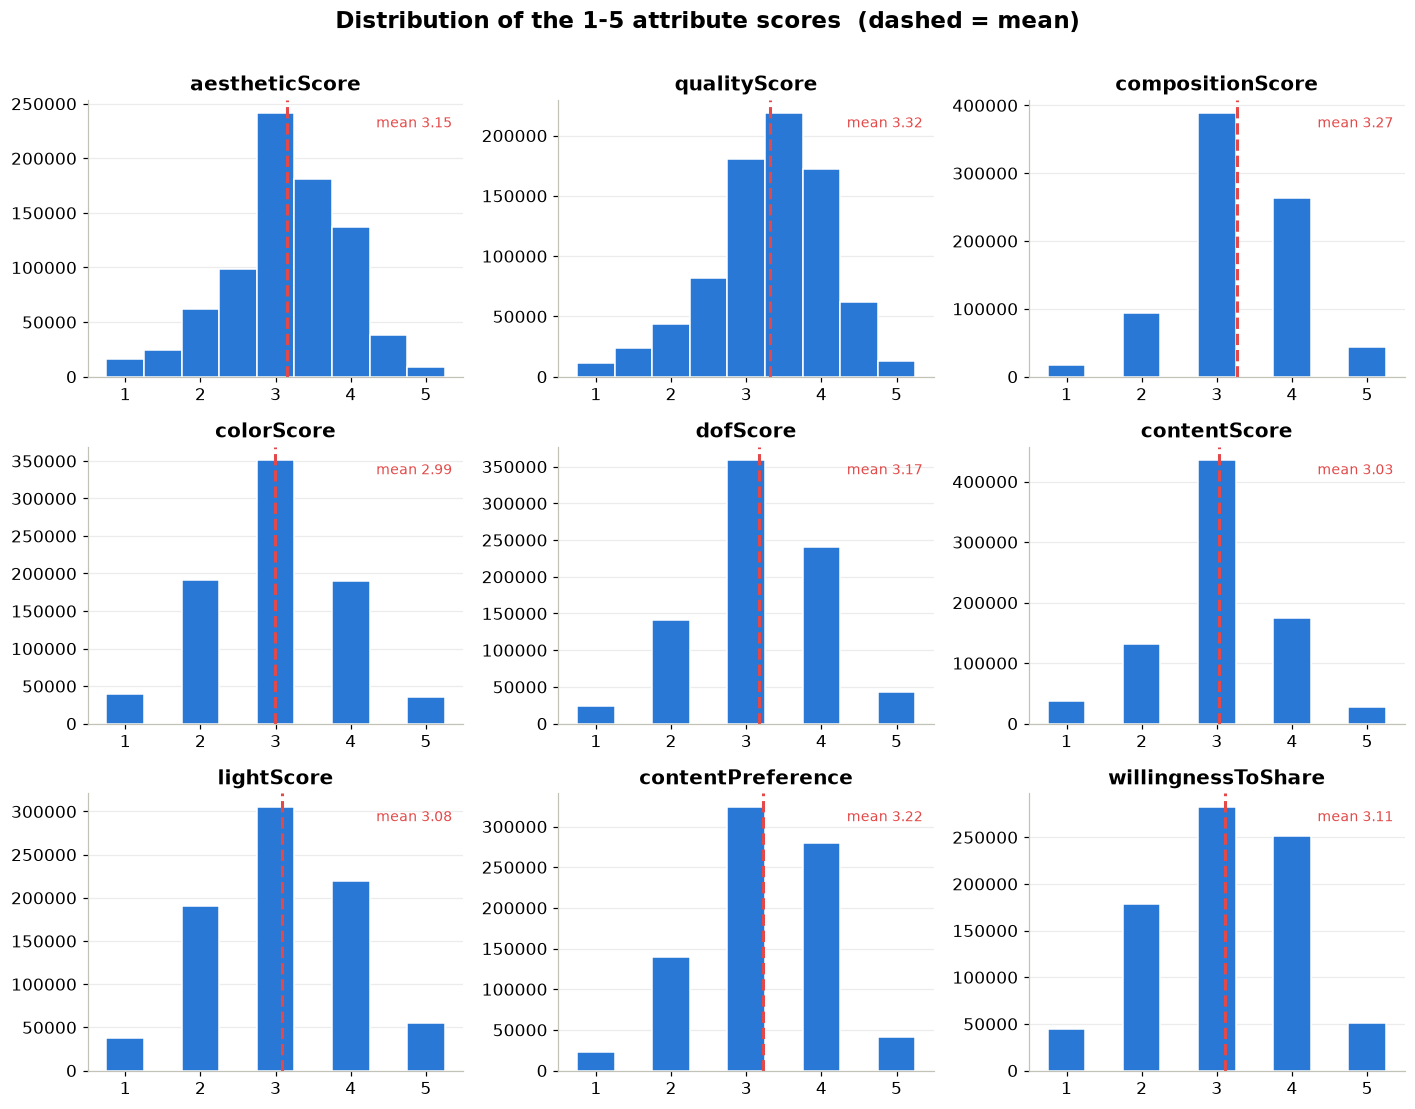

,mean,std,min,25%,50%,75%,max
aestheticScore,3.15,0.78,1.0,3.0,3.0,3.5,5.0
qualityScore,3.32,0.77,1.0,2.9,3.4,3.8,5.0
compositionScore,3.27,0.82,1.0,3.0,3.0,4.0,5.0
colorScore,2.99,0.92,1.0,2.0,3.0,4.0,5.0
dofScore,3.17,0.88,1.0,3.0,3.0,4.0,5.0
contentScore,3.03,0.84,1.0,3.0,3.0,4.0,5.0
lightScore,3.08,0.98,1.0,2.0,3.0,4.0,5.0
contentPreference,3.22,0.89,1.0,3.0,3.0,4.0,5.0
willingnessToShare,3.11,1.00,1.0,2.0,3.0,4.0,5.0


In [5]:
SCORE_COLS = ["aestheticScore", "qualityScore", "compositionScore", "colorScore",
              "dofScore", "contentScore", "lightScore", "contentPreference",
              "willingnessToShare"]

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.ravel(), SCORE_COLS):
    ax.hist(images[col], bins=np.arange(0.75, 5.75, 0.5), color=BLUE, edgecolor="white")
    m = images[col].mean()
    ax.axvline(m, color=RED, lw=2, ls="--")
    ax.set_title(col); ax.set_xlim(0.5, 5.5); ax.grid(axis="x", visible=False)
    ax.annotate(f"mean {m:.2f}", (0.97, 0.9), xycoords="axes fraction",
                ha="right", color=RED, fontsize=9)
fig.suptitle("Distribution of the 1-5 attribute scores  (dashed = mean)",
             y=1.005, fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

display(images[SCORE_COLS].describe().round(2).T[["mean", "std", "min", "25%", "50%", "75%", "max"]])

### 2.2 Categorical attributes: scene, emotion, difficulty, object emphasis

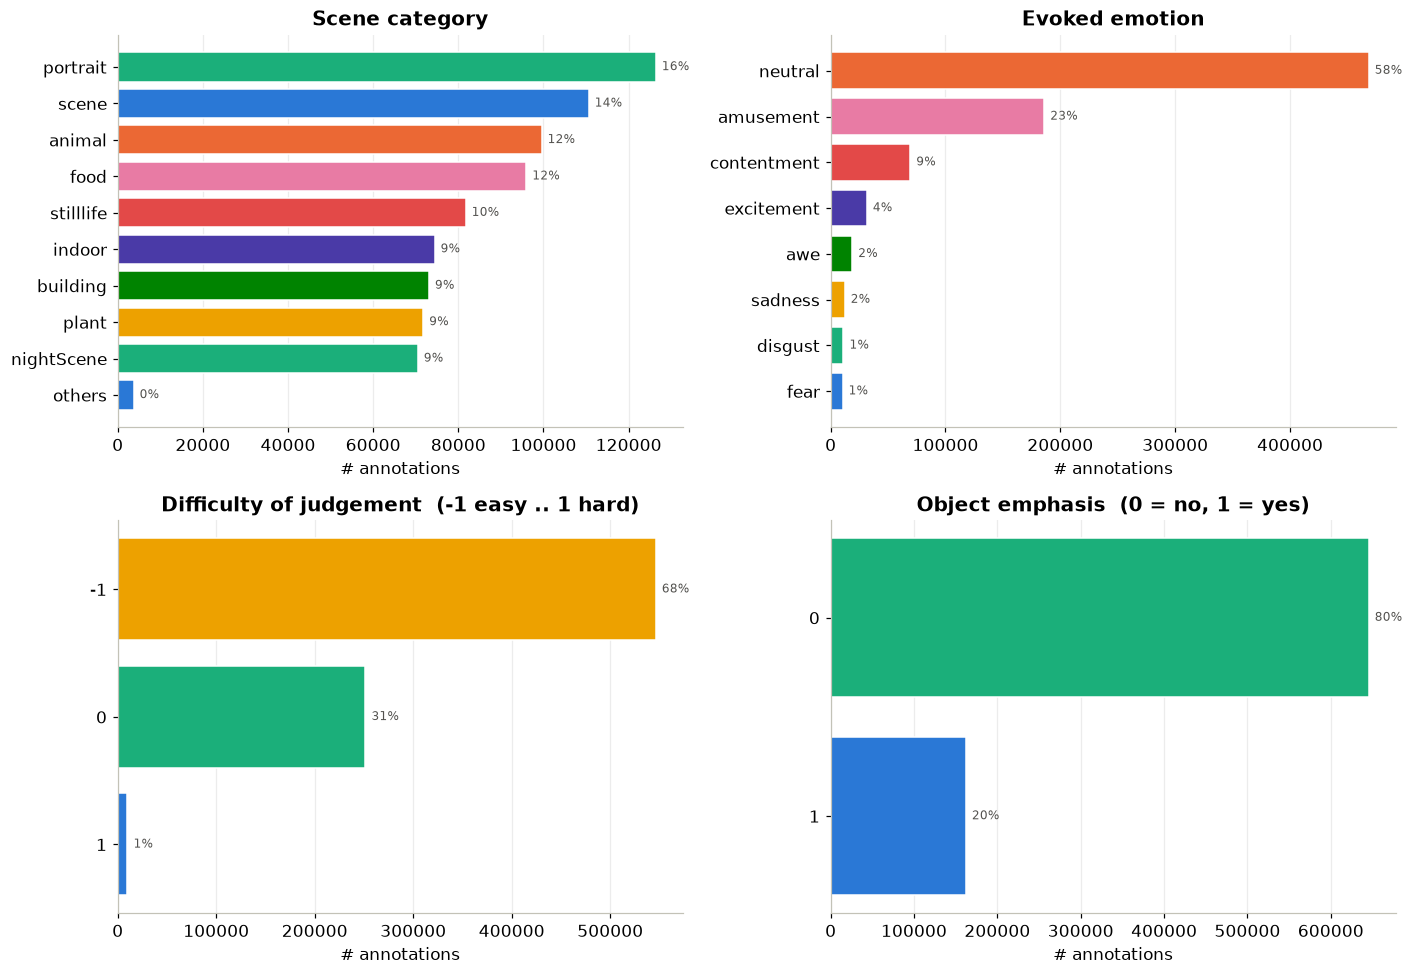

In [6]:
cat_specs = [("semantic", "Scene category"), ("imgEmotion", "Evoked emotion"),
             ("difficultyOfJudgment", "Difficulty of judgement  (-1 easy .. 1 hard)"),
             ("isObjectEmphasis", "Object emphasis  (0 = no, 1 = yes)")]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (col, title) in zip(axes.ravel(), cat_specs):
    vc = images[col].value_counts().sort_values()
    colors = [CATEGORICAL[i % len(CATEGORICAL)] for i in range(len(vc))]
    ax.barh(vc.index.astype(str), vc.values, color=colors, edgecolor="white")
    for y, v in enumerate(vc.values):
        ax.annotate(f"{v/len(images)*100:.0f}%", (v, y), xytext=(4, 0),
                    textcoords="offset points", va="center", fontsize=8, color="#52514e")
    ax.set_title(title); ax.set_xlabel("# annotations"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 3. Correlation analysis

The core question — **what moves together?** All attribute scores are ordinal on a
common 1–5 scale, so a Pearson correlation over the ~808 k raw annotations is
meaningful. The diverging blue↔red map is centred at 0: **blue = positive,
red = negative**.

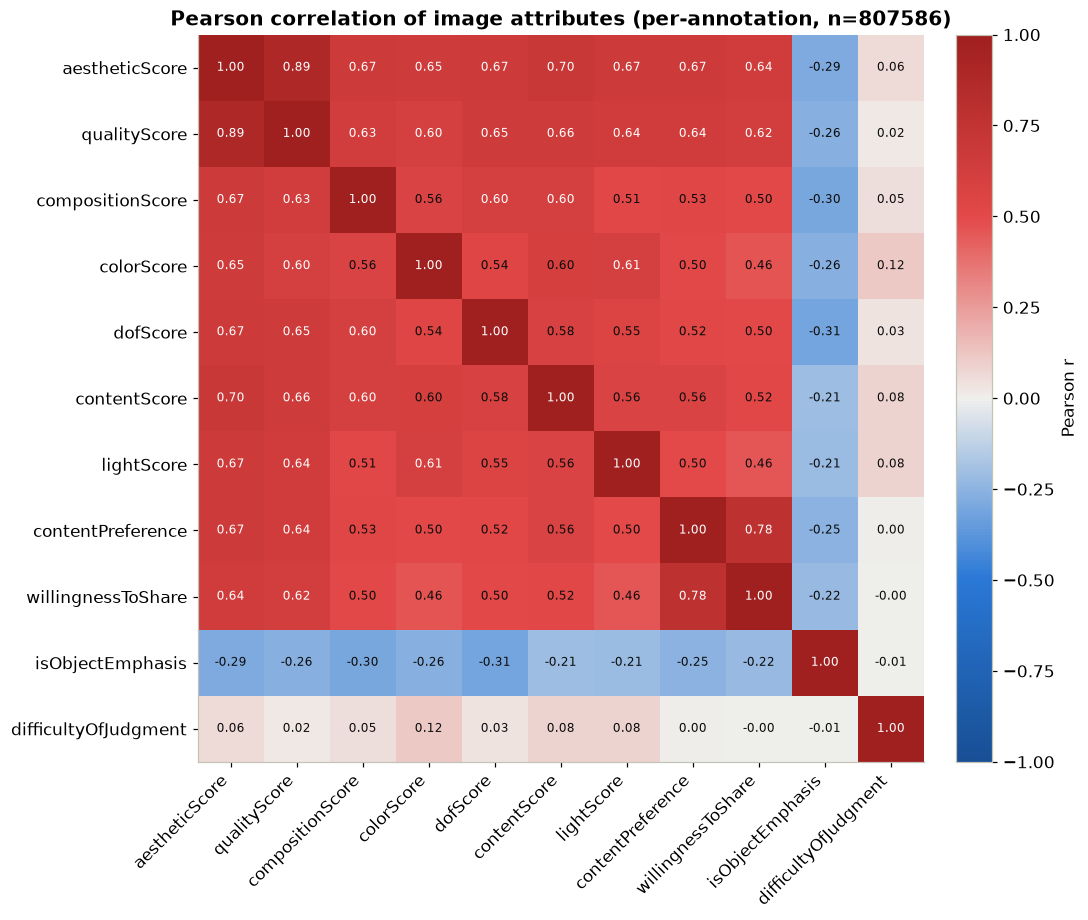

In [7]:
NUMERIC_COLS = SCORE_COLS + ["isObjectEmphasis", "difficultyOfJudgment"]

def annotated_heatmap(mat, ax, title, xlabels=None, ylabels=None,
                      vmin=-1, vmax=1, cmap=DIVERGING, fmt="{:.2f}"):
    # imshow heatmap with per-cell value labels (direct labels satisfy the relief rule)
    mat = np.asarray(mat, dtype=float)
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    if xlabels is not None:
        ax.set_xticks(range(len(xlabels))); ax.set_xticklabels(xlabels, rotation=45, ha="right")
    if ylabels is not None:
        ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels)
    ax.set_title(title); ax.grid(False)
    thr, mid = (vmax - vmin) * 0.30, (vmax + vmin) / 2
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=8,
                    color="white" if abs(v - mid) > thr else "#0b0b0b")
    return im

corr = images[NUMERIC_COLS].corr(method="pearson")
fig, ax = plt.subplots(figsize=(10, 8.5))
im = annotated_heatmap(corr.values, ax,
        "Pearson correlation of image attributes (per-annotation, n=%d)" % len(images),
        xlabels=corr.columns, ylabels=corr.columns)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
plt.tight_layout(); plt.show()

### 3.1 What drives the aesthetic score?

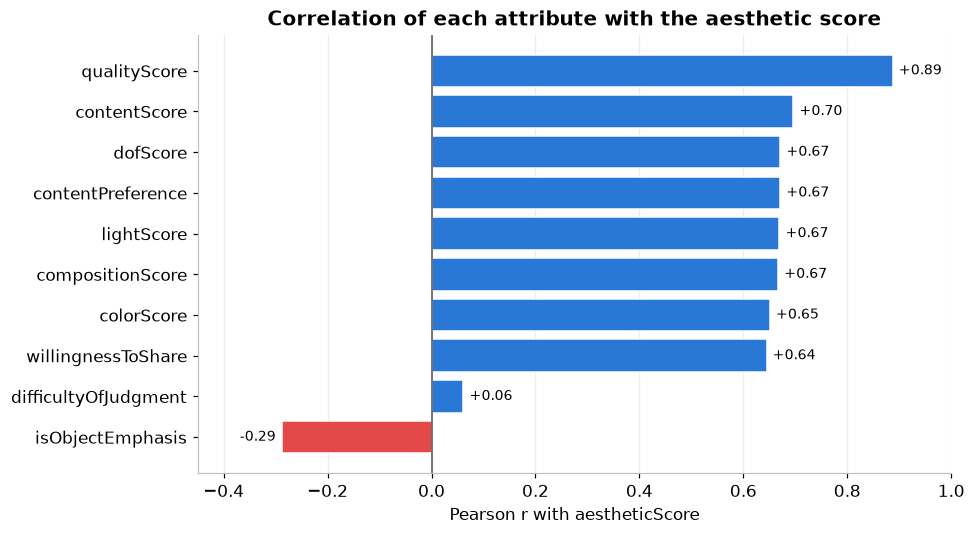

In [8]:
target = "aestheticScore"
s = corr[target].drop(target).sort_values()
colors = [RED if v < 0 else BLUE for v in s.values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(s.index, s.values, color=colors, edgecolor="white")
for y, v in enumerate(s.values):
    ax.annotate(f"{v:+.2f}", (v, y), xytext=(4 if v >= 0 else -4, 0),
                textcoords="offset points", va="center",
                ha="left" if v >= 0 else "right", fontsize=9)
ax.axvline(0, color="#52514e", lw=1)
ax.set(title="Correlation of each attribute with the aesthetic score",
       xlabel="Pearson r with aestheticScore", xlim=(-0.45, 1.0))
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

### 3.2 Aesthetic score by scene and by emotion

Correlation only covers the numeric columns. For the two big categorical
attributes we compare the **mean aesthetic score** each group receives
(bars are ±1 SD).

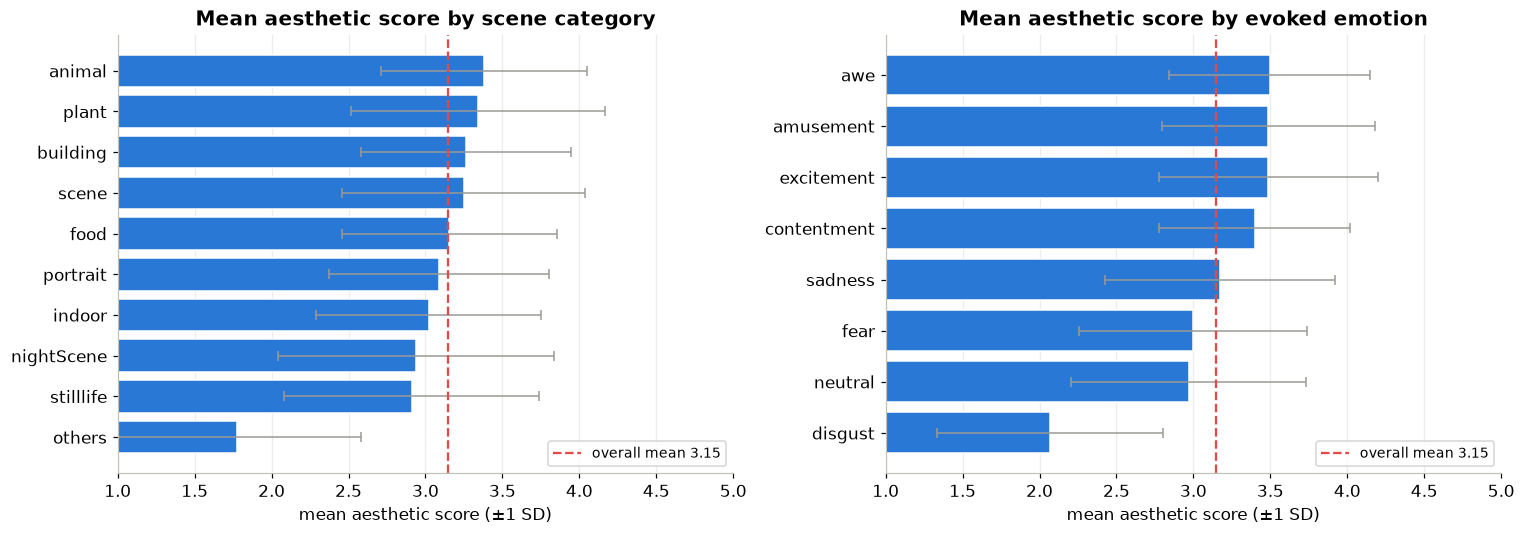

In [9]:
specs = [("semantic", "Mean aesthetic score by scene category"),
         ("imgEmotion", "Mean aesthetic score by evoked emotion")]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (col, title) in zip(axes, specs):
    grp = images.groupby(col)["aestheticScore"].agg(["mean", "std"]).sort_values("mean")
    ax.barh(grp.index, grp["mean"], xerr=grp["std"], color=BLUE, edgecolor="white",
            error_kw=dict(ecolor="#9a9a94", lw=1, capsize=3))
    ax.axvline(images["aestheticScore"].mean(), color=RED, ls="--", lw=1.5,
               label=f"overall mean {images['aestheticScore'].mean():.2f}")
    ax.set(title=title, xlabel="mean aesthetic score (±1 SD)", xlim=(1, 5))
    ax.grid(axis="y", visible=False); ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

## 4. The annotators

PARA is *personalized*: who does the rating matters. Here are the 438 annotators.

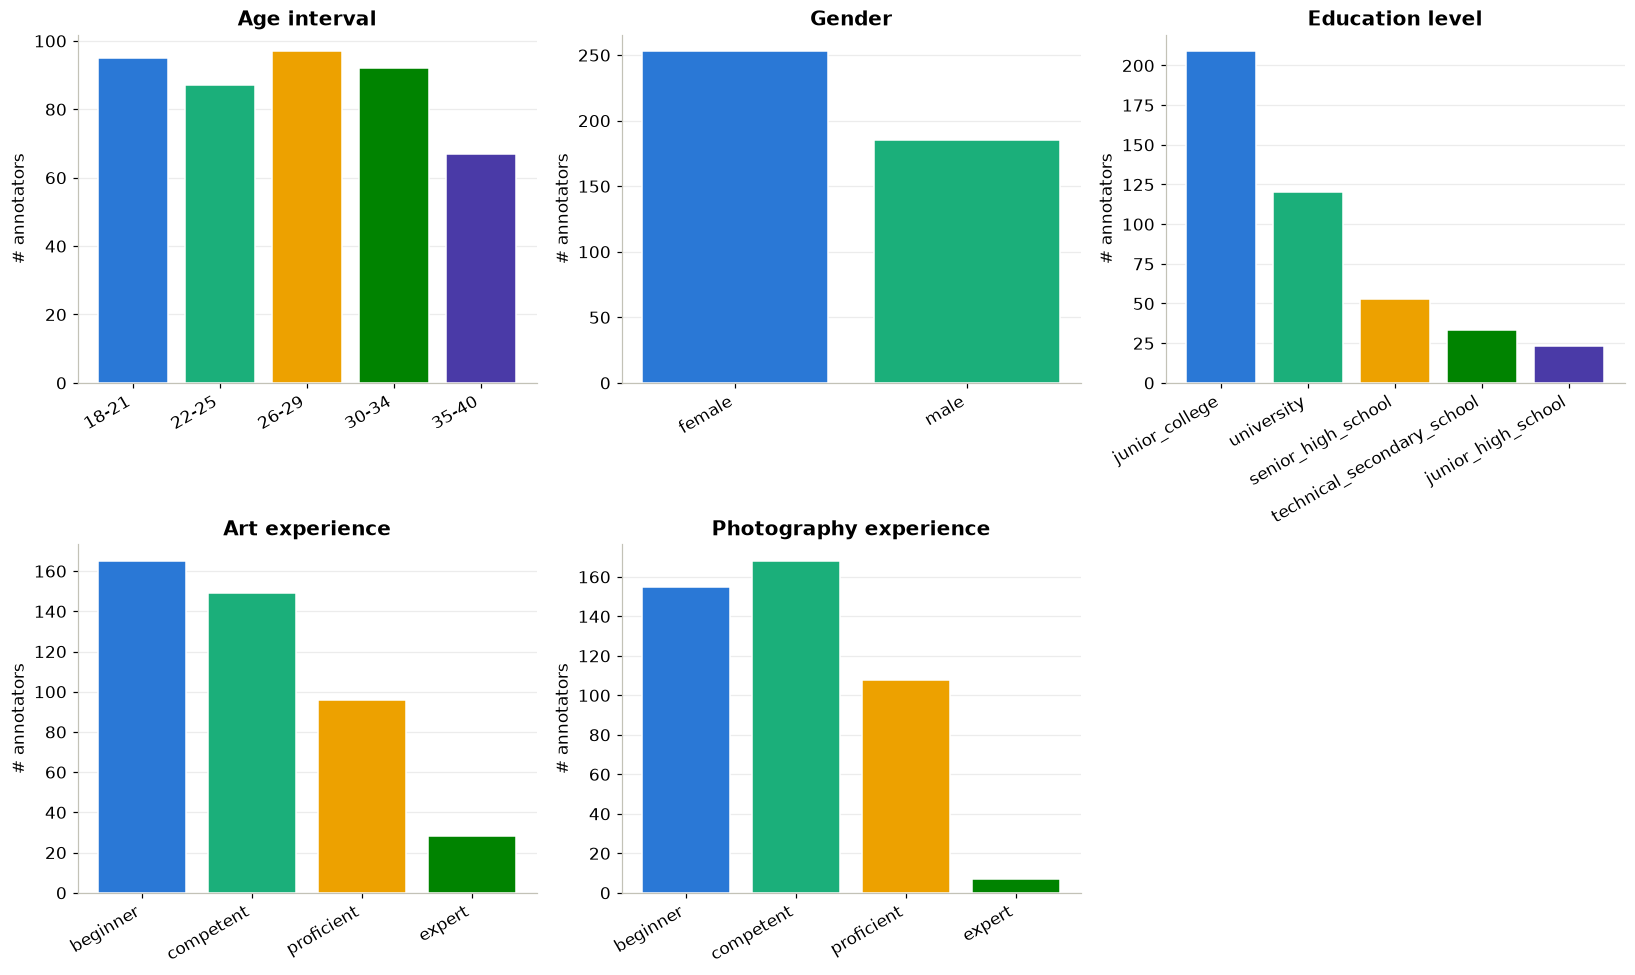

In [10]:
demo_specs = [("age", "Age interval"), ("gender", "Gender"),
              ("EducationalLevel", "Education level"),
              ("artExperience", "Art experience"),
              ("photographyExperience", "Photography experience")]
order = {"age": ["18-21", "22-25", "26-29", "30-34", "35-40"],
         "artExperience": ["beginner", "competent", "proficient", "expert"],
         "photographyExperience": ["beginner", "competent", "proficient", "expert"]}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (col, title) in zip(axes.ravel(), demo_specs):
    vc = users[col].value_counts()
    vc = vc.reindex(order[col]) if col in order else vc.sort_values(ascending=False)
    ax.bar(vc.index.astype(str), vc.values, color=CATEGORICAL[:len(vc)], edgecolor="white")
    ax.set(title=title, ylabel="# annotators"); ax.grid(axis="x", visible=False)
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(30); lbl.set_ha("right")
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

### 4.1 Big-Five personality — distributions and inter-trait correlation

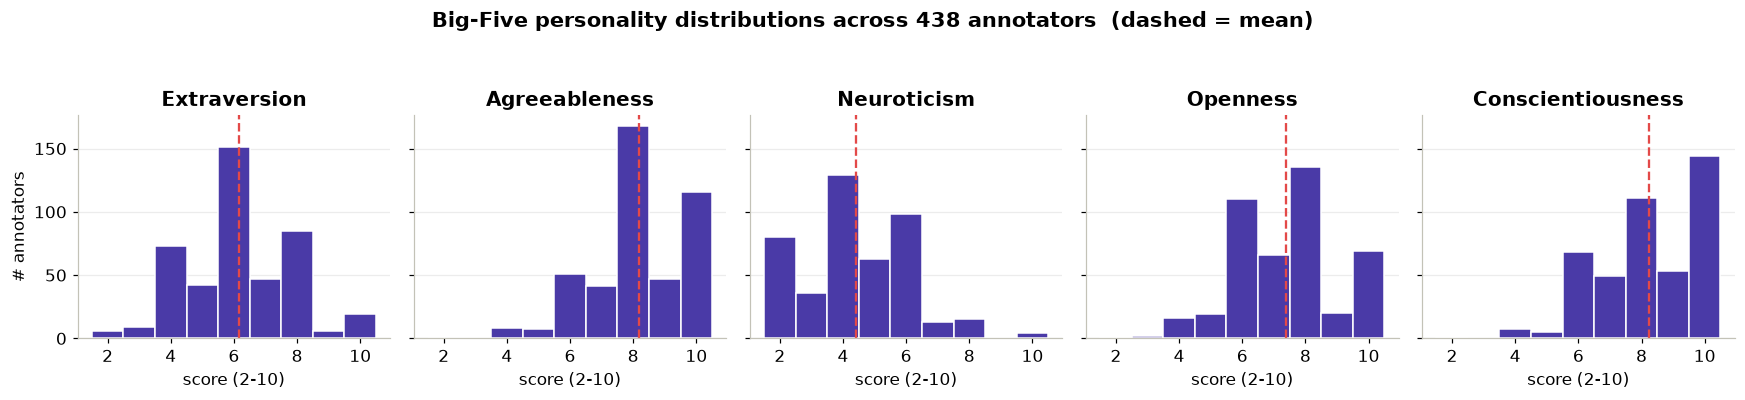

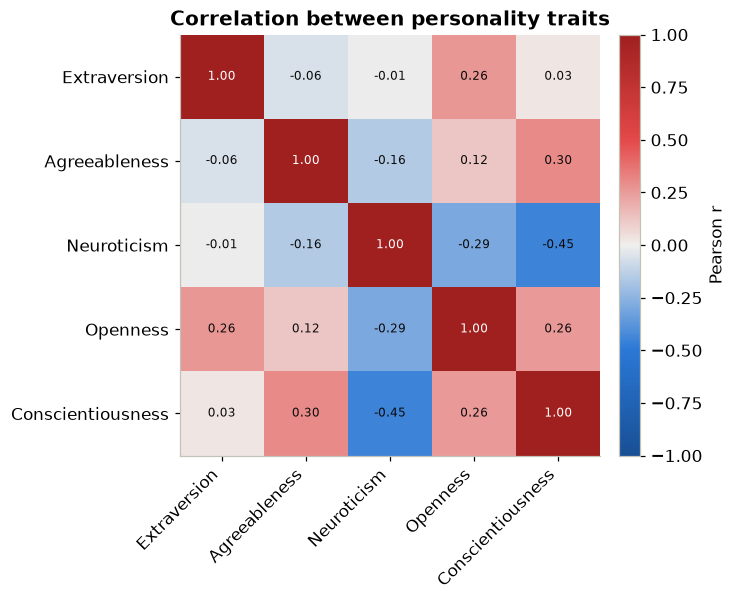

In [11]:
TRAITS = ["personality-E", "personality-A", "personality-N", "personality-O", "personality-C"]
NAMES  = ["Extraversion", "Agreeableness", "Neuroticism", "Openness", "Conscientiousness"]

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4), sharey=True)
for ax, col, name in zip(axes, TRAITS, NAMES):
    ax.hist(users[col], bins=np.arange(1.5, 11.5, 1), color=VIOLET, edgecolor="white")
    ax.axvline(users[col].mean(), color=RED, ls="--", lw=1.5)
    ax.set(title=name, xlabel="score (2-10)")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("# annotators")
fig.suptitle("Big-Five personality distributions across 438 annotators  (dashed = mean)",
             y=1.06, fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

tcorr = users[TRAITS].corr()
fig, ax = plt.subplots(figsize=(6.8, 5.6))
im = annotated_heatmap(tcorr.values, ax, "Correlation between personality traits",
                       xlabels=NAMES, ylabels=NAMES)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
plt.tight_layout(); plt.show()

### 4.2 Do annotator traits predict the scores they give?

Aggregate each annotator to their **mean given score**, join their traits, and
correlate. A near-zero row means that trait does *not* explain systematic
leniency/harshness. (Note the smaller ±0.5 colour range here.)

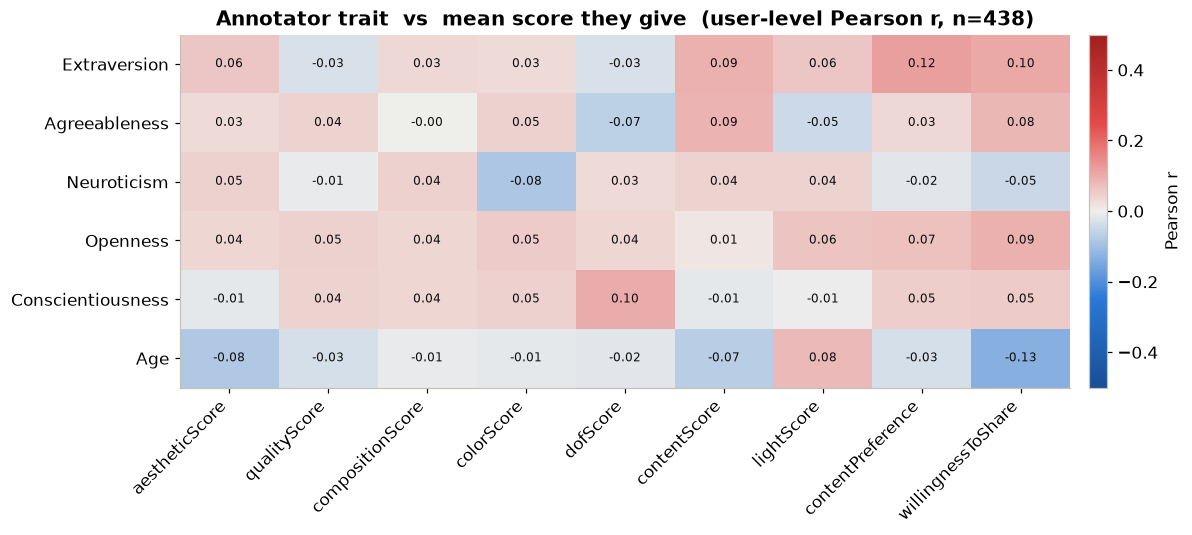

In [12]:
AGE_MID = {"18-21": 19.5, "22-25": 23.5, "26-29": 27.5, "30-34": 32, "35-40": 37.5}

user_mean = images.groupby("userId")[SCORE_COLS].mean()
udf = users.set_index("userId").join(user_mean)
udf["ageMid"] = udf["age"].map(AGE_MID)

rows   = TRAITS + ["ageMid"]
rlabel = NAMES + ["Age"]
cross = np.array([[udf[r].corr(udf[c]) for c in SCORE_COLS] for r in rows])

fig, ax = plt.subplots(figsize=(11, 5))
im = annotated_heatmap(cross, ax,
        "Annotator trait  vs  mean score they give  (user-level Pearson r, n=%d)" % len(udf),
        xlabels=SCORE_COLS, ylabels=rlabel, vmin=-0.5, vmax=0.5)
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Pearson r")
plt.tight_layout(); plt.show()

## 5. Key findings

In [13]:
# Programmatic summary — numbers are computed, not hard-coded.
aest = corr["aestheticScore"].drop("aestheticScore")
scene_mean = images.groupby("semantic")["aestheticScore"].mean().sort_values()
emo_mean   = images.groupby("imgEmotion")["aestheticScore"].mean().sort_values()
trait_leniency = {n: udf[t].corr(udf["aestheticScore"]) for t, n in zip(TRAITS, NAMES)}
strongest_trait = max(trait_leniency.items(), key=lambda kv: abs(kv[1]))

print("KEY FINDINGS")
print("-" * 64)
print(f"1. Scale       : {len(images):,} annotations, {images.imageName.nunique():,} images,"
      f" {images.userId.nunique()} annotators, 0 missing values.")
print(f"2. Aesthetic <-> quality are near-duplicate: r = {aest['qualityScore']:.2f}.")
print(f"3. All aesthetic sub-attributes move together (r ~ 0.65-0.70);"
      f" content/dof/light lead among the perceptual ones.")
print(f"4. isObjectEmphasis is the only NEGATIVE driver of aesthetics"
      f" (r = {aest['isObjectEmphasis']:.2f}); difficulty is ~uncorrelated (r = {aest['difficultyOfJudgment']:.2f}).")
print(f"5. contentPreference <-> willingnessToShare r = {corr.loc['contentPreference','willingnessToShare']:.2f}"
      f" (liking the content ~ wanting to share).")
print(f"6. Best-rated scenes : {', '.join(scene_mean.index[-3:][::-1])};"
      f"  worst : {', '.join(scene_mean.index[:3])}.")
print(f"7. Emotion matters   : positive emotions (awe/amusement/excitement ~{emo_mean.iloc[-1]:.2f})"
      f" beat 'disgust' ({emo_mean['disgust']:.2f}).")
print(f"8. Annotator traits barely predict leniency: strongest is"
      f" {strongest_trait[0]} at r = {strongest_trait[1]:+.2f} -> aesthetic judgement is"
      f" mostly image-driven, not personality-driven, at the population level.")

KEY FINDINGS
----------------------------------------------------------------
1. Scale       : 807,586 annotations, 31,220 images, 438 annotators, 0 missing values.
2. Aesthetic <-> quality are near-duplicate: r = 0.89.
3. All aesthetic sub-attributes move together (r ~ 0.65-0.70); content/dof/light lead among the perceptual ones.
4. isObjectEmphasis is the only NEGATIVE driver of aesthetics (r = -0.29); difficulty is ~uncorrelated (r = 0.06).
5. contentPreference <-> willingnessToShare r = 0.78 (liking the content ~ wanting to share).
6. Best-rated scenes : animal, plant, building;  worst : others, stilllife, nightScene.
7. Emotion matters   : positive emotions (awe/amusement/excitement ~3.50) beat 'disgust' (2.07).
8. Annotator traits barely predict leniency: strongest is Extraversion at r = +0.06 -> aesthetic judgement is mostly image-driven, not personality-driven, at the population level.


### Takeaways

- **The dataset is dense and clean.** ~808 k annotations over 31 k images, ~26
  raters each, zero missing values — well suited for both generic (GIAA) and
  personalized (PIAA) aesthetics modelling.
- **The aesthetic score is highly redundant with the other attributes.** Quality
  is almost a proxy (r ≈ 0.89), and every perceptual sub-score correlates ~0.65–0.70
  with it. A model predicting aesthetics can lean heavily on these.
- **`isObjectEmphasis` is the interesting negative signal** — images flagged as
  having a single emphasised object tend to score *lower* on aesthetics here.
- **Content and emotion carry real signal**: scene category and evoked emotion
  shift the mean aesthetic score by a full point or more (e.g. *disgust* ≈ 2.1 vs
  *awe* ≈ 3.5).
- **Personalization is subtle.** At the population level, an annotator's Big-Five
  traits and age barely predict how generous their scores are (|r| < 0.1). The
  personalization signal in PARA lives in *image × person* interactions, not in
  a global "this personality rates higher" effect — which is exactly why PIAA is
  framed as a per-user modelling problem.